In [2]:
#Kümeleme
#K ortalama kümeleme (gözetimsiz öğrenme):  

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


In [ ]:
#veri seti oluştur

#küme 1:
x1 = np.random.normal(25, 5, 1000) #(ortalama, standart sapma, kaç tane sayı) 
y1 = np.random.normal(25, 5, 1000)

#küme 2 :
x2= np.random.normal(55, 5, 1000)
y2= np.random.normal(60, 5, 1000)

#küme 3 :
x3= np.random.normal(55, 5, 1000)
y3= np.random.normal(15, 5, 1000)

x = np.concatenate((x1, x2, x3), axis = 0) #x'ler birleşiyor
y = np.concatenate((y1, y2, y3), axis = 0) #y'ler birleşiyor

dictionary = {"x" : x, "y" : y}

data = pd.DataFrame(dictionary)
data.head()
data.info()
#excel için data.Tocsv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       3000 non-null   float64
 1   y       3000 non-null   float64
dtypes: float64(2)
memory usage: 47.0 KB


In [5]:
print(np.sort(x2))

[39.64003619 39.874694   41.04551174 42.28169477 42.59880229 42.90710756
 43.06991795 43.2421466  43.34798233 43.35699455 43.52569796 43.6291619
 43.73408061 43.95685763 44.13743052 44.15880477 44.20387319 44.30688002
 44.33021174 44.37228172 44.38686554 44.68509343 44.69017351 44.75144394
 45.02491719 45.03727623 45.04838657 45.05885526 45.18219499 45.23054059
 45.26441682 45.32441274 45.59469111 45.6209882  45.67726737 45.73236019
 45.76972477 45.94765962 46.18183476 46.27452678 46.36531629 46.38579856
 46.47102223 46.47588142 46.5619182  46.58734069 46.67366883 46.67913524
 46.8685218  46.90909184 46.9428865  47.01233573 47.0175416  47.0242318
 47.03711752 47.04176856 47.0533145  47.08178492 47.08215214 47.08607285
 47.10929174 47.11171259 47.21534309 47.2456843  47.25695563 47.29478876
 47.32634894 47.39079539 47.41179616 47.41439462 47.49381646 47.49842269
 47.51496188 47.53056223 47.56983438 47.5940841  47.60196372 47.61558626
 47.61957823 47.62004377 47.62471124 47.6634048  47.6

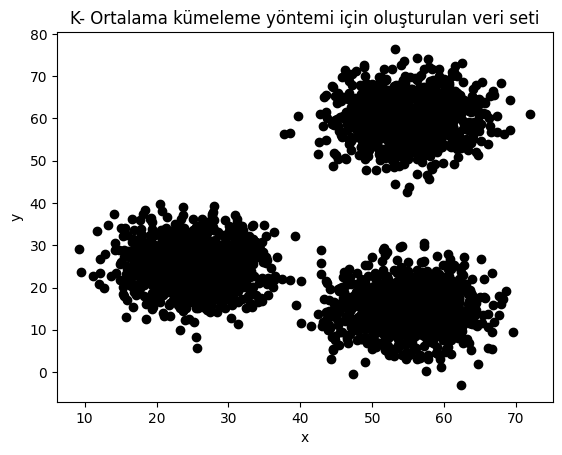

In [ ]:
plt.figure()
plt.scatter(x1, y1, color = "black") #, color = "black"
plt.scatter(x2, y2, color = "black")
plt.scatter(x3, y3, color = "black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("K- Ortalama kümeleme yöntemi için oluşturulan veri seti")
plt.show()

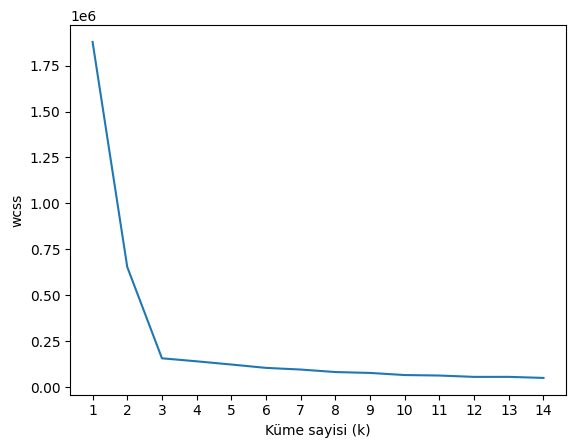

In [ ]:
#K değerinin seçimi: Dirsek yöntemi
#K ortalamayı içe aktar
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 15):
    kmeans = KMeans(n_clusters= k) #cluster 1 olacak şekilde
    kmeans.fit(data)
    wcss.append(kmeans.inertia_) #
    
plt.figure()
plt.plot(range(1, 15), wcss) #15 dahil değil.
plt.xticks(range(1, 15))
plt.xlabel("Küme sayisi (k)")
plt.ylabel("wcss")
plt.show()

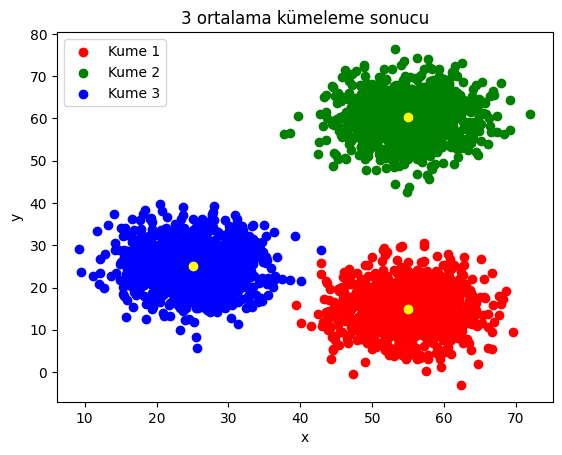

In [17]:
k_ortalama = KMeans(n_clusters= 3 )
kumeler = k_ortalama.fit_predict(data)

data["label"] = kumeler

plt.figure()
plt.scatter(data.x[data.label == 0], data.y[data.label == 0], color = "red", label = "Kume 1")
plt.scatter(data.x[data.label == 1], data.y[data.label == 1], color = "green", label = "Kume 2")
plt.scatter(data.x[data.label == 2], data.y[data.label == 2], color = "blue", label = "Kume 3")
plt.scatter(k_ortalama.cluster_centers_[:,0], k_ortalama.cluster_centers_[:, 1], color  = "yellow")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("3 ortalama kümeleme sonucu")
plt.show()

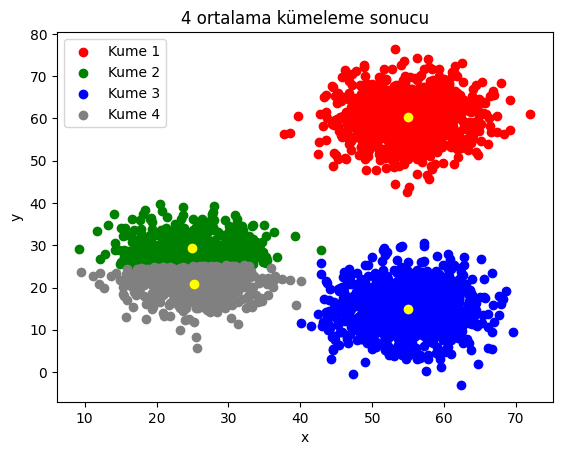

In [24]:
k_ortalama = KMeans(n_clusters= 4 )
kumeler = k_ortalama.fit_predict(data)

data["label"] = kumeler

plt.figure()
plt.scatter(data.x[data.label == 0], data.y[data.label == 0], color = "red", label = "Kume 1")
plt.scatter(data.x[data.label == 1], data.y[data.label == 1], color = "green", label = "Kume 2")
plt.scatter(data.x[data.label == 2], data.y[data.label == 2], color = "blue", label = "Kume 3")
plt.scatter(data.x[data.label == 3], data.y[data.label == 3], color = "gray", label = "Kume 4")
plt.scatter(k_ortalama.cluster_centers_[:,0], k_ortalama.cluster_centers_[:, 1], color  = "yellow")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("4 ortalama kümeleme sonucu")
plt.show()

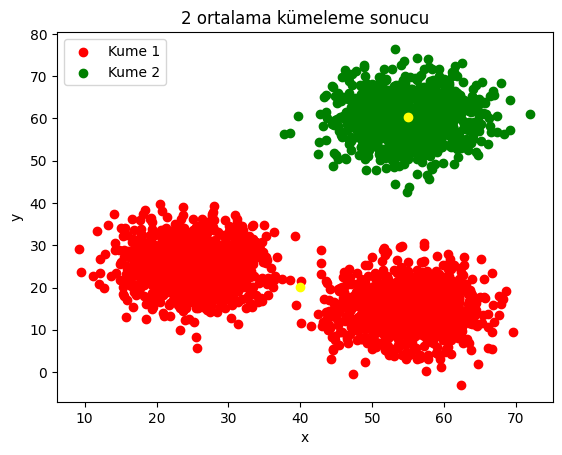

In [25]:
k_ortalama = KMeans(n_clusters= 2 )
kumeler = k_ortalama.fit_predict(data)

data["label"] = kumeler

plt.figure()
plt.scatter(data.x[data.label == 0], data.y[data.label == 0], color = "red", label = "Kume 1")
plt.scatter(data.x[data.label == 1], data.y[data.label == 1], color = "green", label = "Kume 2")
plt.scatter(k_ortalama.cluster_centers_[:,0], k_ortalama.cluster_centers_[:, 1], color  = "yellow")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("2 ortalama kümeleme sonucu")
plt.show()